In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/test_lncAPNet/Pilot_3_TCGA_Breast/notebooks/Post-hoc_Analysis


In [2]:
# Libraries
import numpy as np
import re
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import networkx as nx
from adjustText import adjust_text
import openpyxl

import gc
import re
import random
import math

import stringdb
import string
import logging

import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import Normalize, LinearSegmentedColormap

from scipy.cluster.hierarchy import linkage, leaves_list
import igraph as ig
import leidenalg


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, leaves_list

In [3]:
gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_go = pd.read_excel("../../PASNet/Output/GO/PASNet_sc1_weight_matrix.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/GO/pt_fixed.xlsx", index_col=0)

sc1_go.columns = pt.columns
sc1_go.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_go.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_go = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_go = df_go[df_go['Weight'] != 0]

In [4]:
pasnet_genes_go = df_go['target'].unique()
print(len(pasnet_genes_go))

2291


In [5]:
shap_validation_go = pd.read_csv("../../PASNet/Output/GO/feature_importance.csv", index_col=0)
shap_validation_go_top50 = shap_validation_go.sort_values(by="Importance", ascending=False).head(50)

In [6]:
import pandas as pd

# Step 1: Get the feature names (index) from the DataFrame
features_go = shap_validation_go_top50.index

# Step 2: Remove duplicates
unique_features = pd.Index(features_go).unique()

# Step 3: Append the new features correctly using a pandas Index
new_features = pd.Index(["DSCAM-AS1", "AFAP1-AS1"])
unique_features = unique_features.append(new_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [7]:
# Assuming your DataFrame is called df
table_go = df_go.pivot_table(
    index='source',      # rows
    columns='target',    # columns
    values='Weight',     # values to fill
    fill_value=0         # fill missing with 0
)

# Optional: reset column names if needed
table_go = table_go.reset_index()

In [8]:
def filter_table(table, features_df):
    # Set 'source' as index if not already
    table_indexed = table.set_index('source')
    
    # Keep only columns present in features_df['Feature']
    filtered_table = table_indexed[table_indexed.columns.intersection(features_df['Feature'])]
    
    # Keep only rows where the sum across columns is not 0
    filtered_table = filtered_table[filtered_table.sum(axis=1) != 0]
    
    # Reset index to bring 'source' back as a column
    return filtered_table.reset_index()

# Apply the function to both tables
filtered_table_go = filter_table(table_go, features_df)

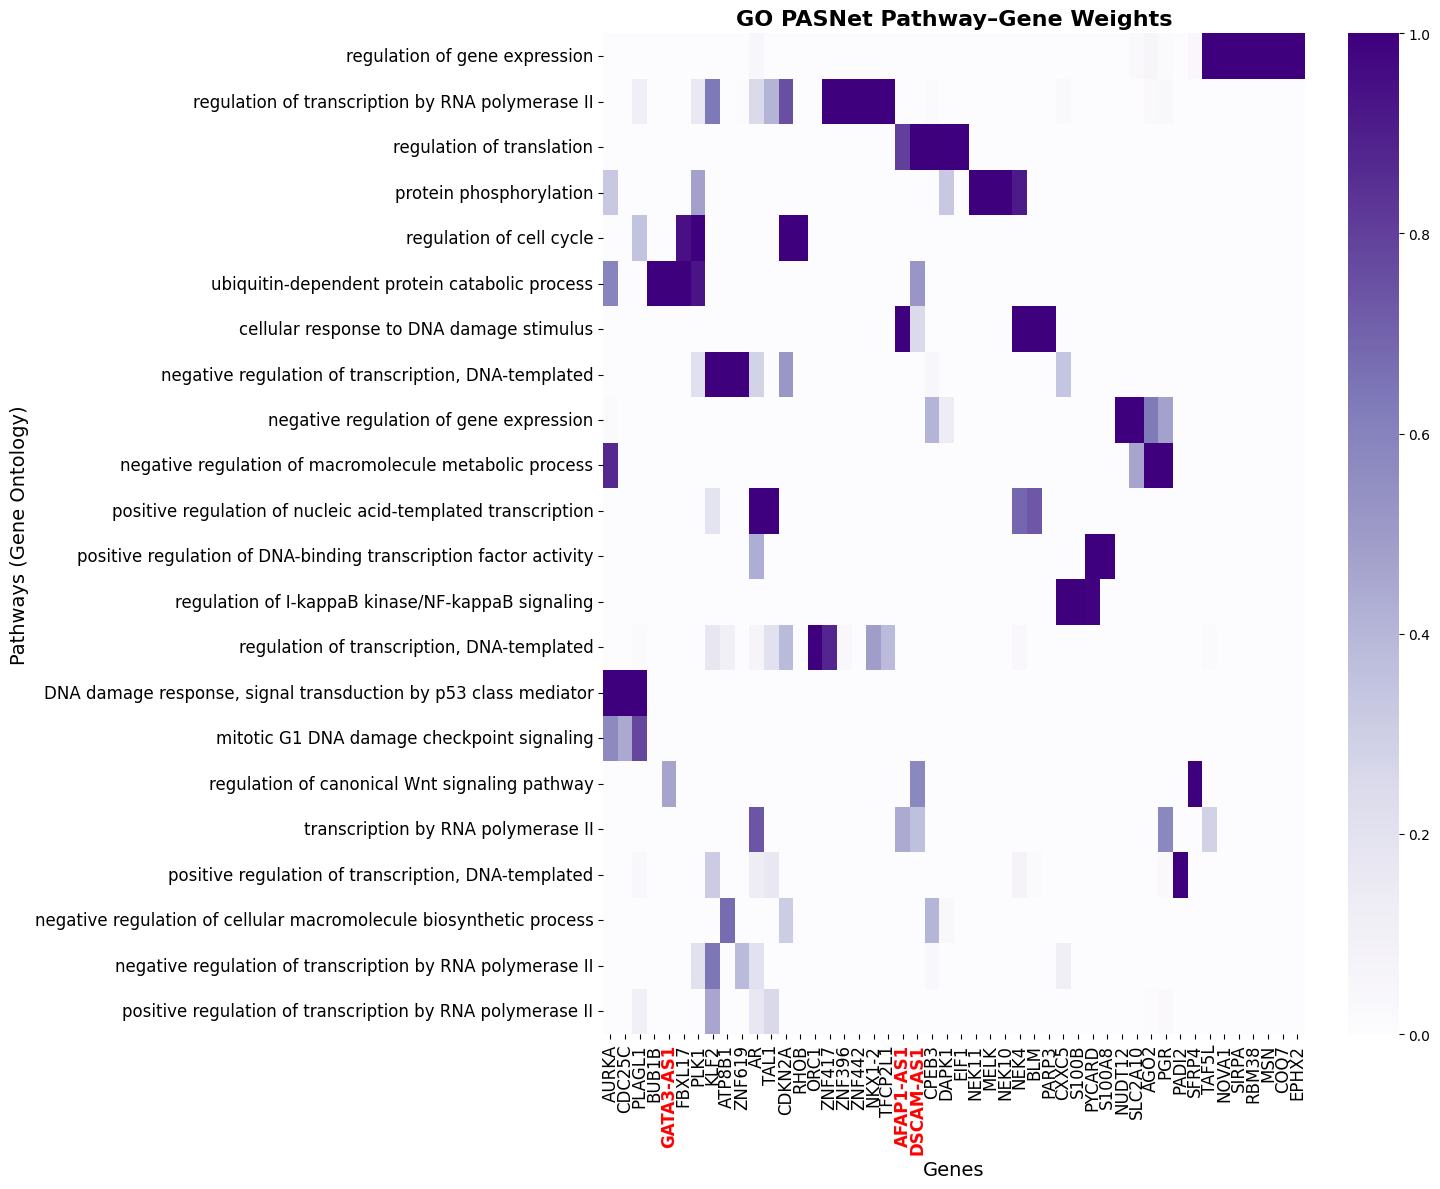

In [9]:
# --- Example test genes ---
test_genes = ["GATA3-AS1", "DSCAM-AS1", "AFAP1-AS1"]

# ===============================================================
# 1. Fill missing gene values with 0 (numeric columns only)
# ===============================================================
numeric_cols = filtered_table_go.columns.difference(['source'])
filtered_table_go[numeric_cols] = filtered_table_go[numeric_cols].fillna(0)

# ===============================================================
# 2. Take absolute values
# ===============================================================
filtered_table_go[numeric_cols] = filtered_table_go[numeric_cols].abs()

# ===============================================================
# 3. Filter rows and columns
# ===============================================================
def filter_rows_cols(df, min_nonzero_rows=2, min_nonzero_cols=1):
    df = df.copy()
    # Keep pathways with >= min_nonzero_rows non-zero genes
    df = df[df[numeric_cols].gt(0).sum(axis=1) >= min_nonzero_rows]
    # Keep genes present in >= min_nonzero_cols pathways
    nonzero_genes = df[numeric_cols].gt(0).sum(axis=0) >= min_nonzero_cols
    df = pd.concat([df[['source']], df[numeric_cols].loc[:, nonzero_genes]], axis=1)
    return df

filtered_table_go = filter_rows_cols(filtered_table_go, min_nonzero_rows=3, min_nonzero_cols=1)

# ===============================================================
# 4. Recompute numeric_cols after filtering
# ===============================================================
numeric_cols = filtered_table_go.columns.difference(['source'])

# ===============================================================
# 5. Clean pathway/source names
# ===============================================================
def clean_source_names(df):
    df = df.copy()
    df['source'] = df['source'].str.replace(r"\s*\(GO:[^)]+\)", "", regex=True)
    df['source'] = df['source'].str.replace(r"\s*R-HSA-\d+$", "", regex=True)
    df['source'] = df['source'].str.replace(r"\s*WP\d+$", "", regex=True)
    return df

filtered_table_go = clean_source_names(filtered_table_go)
filtered_table_go_for_next_steps = filtered_table_go

# Shorten long pathway names
filtered_table_go['source'] = filtered_table_go['source'].replace(
    "Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers",
    "Signal Transduction By Growth Factor Receptors, Second Messengers"
)

# ===============================================================
# 6. Normalize numeric values (Min–Max scaling 0–10)
# ===============================================================
def scale_dataframe(df, feature_range=(0, 1)):
    data = df[numeric_cols]
    scaler = MinMaxScaler(feature_range=feature_range)
    scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns, index=df.index)
    df_scaled = pd.concat([df[['source']], scaled], axis=1)
    return df_scaled

filtered_table_go = scale_dataframe(filtered_table_go)

# ===============================================================
# 7. Hierarchical clustering function
# ===============================================================
def cluster_dataframe(df):
    data = df[numeric_cols]
    # Cluster rows (pathways)
    row_linkage = linkage(data, method='average', metric='euclidean')
    row_order = leaves_list(row_linkage)
    # Cluster columns (genes)
    col_linkage = linkage(data.T, method='average', metric='euclidean')
    col_order = leaves_list(col_linkage)
    # Reorder dataframe
    clustered_df = df.iloc[row_order, :]
    clustered_df = clustered_df.iloc[:, [0] + (col_order + 1).tolist()]
    return clustered_df

clustered_filtered_table_go = cluster_dataframe(filtered_table_go)

# ===============================================================
# 8. Highlight function for test genes
# ===============================================================
def color_xticklabels(ax, test_genes):
    for tick in ax.get_xticklabels():
        if tick.get_text() in test_genes:
            tick.set_color('red')
            tick.set_fontweight('bold')
        else:
            tick.set_color('black')
            tick.set_fontweight('normal')
    ax.tick_params(axis='x', rotation=90)

# ===============================================================
# 9. Plot filtered_table_go clustered heatmap
# ===============================================================
plt.figure(figsize=(15, 12))
sns.heatmap(
    clustered_filtered_table_go.set_index('source'),
    cmap='Purples',
    annot=False,
    yticklabels=True
)
plt.title('GO PASNet Pathway–Gene Weights', fontsize=16, fontweight='bold')
plt.xlabel('Genes', fontsize=14)
plt.ylabel('Pathways (Gene Ontology)', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)

ax = plt.gca()
color_xticklabels(ax, test_genes)

plt.tight_layout()
plt.savefig("../../figures/Main_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [10]:
pathways = clustered_filtered_table_go['source'].tolist()
gene_list = sorted(set(clustered_filtered_table_go.columns[1:].tolist()))

print(len(pathways))
print(len(gene_list))

22
48


In [11]:
# First, ensure 'source' is the index if not already
filtered_table_go_for_next_steps_temp = filtered_table_go_for_next_steps.set_index('source')

# Reset index so that the rownames become a column
df_reset = filtered_table_go_for_next_steps_temp.reset_index()

# Melt the dataframe
long_df = df_reset.melt(id_vars='source', var_name='column_name', value_name='value')

# Rename columns if you want specific names
long_df = long_df.rename(columns={'source': 'row_name'})

long_df = df_reset.melt(id_vars='source', var_name='target', value_name='weights')

long_df = long_df[long_df['weights'] != 0]

filtered_table_go_df = long_df

filtered_table_go_df['MI'] = None
filtered_table_go_df['spearman'] = None
filtered_table_go_df['p-value'] = None

In [12]:
## NetBID2 results

In [13]:
res = pd.read_excel("../../results/TCGA_Breast/Breast_NetBID2_ms_tab.xlsx")
res = res[['originalID', 'funcType', 'Size', 
                     'logFC.Basal.Vs.LumA_DA', 
                     'adj.P.Val.Basal.Vs.LumA_DA', 'Z.Basal.Vs.LumA_DA', 
                     'logFC.Basal.Vs.LumA_DE', 
                     'adj.P.Val.Basal.Vs.LumA_DE', 
                     'Z.Basal.Vs.LumA_DE']]
res.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.Basal.Vs.LumA_DA': 'logFC_DA',
    'adj.P.Val.Basal.Vs.LumA_DA': 'adj.P.Val_DA',
    'Z.Basal.Vs.LumA_DA': 'Z-score_DA',
    'logFC.Basal.Vs.LumA_DE': 'logFC_DE',
    'adj.P.Val.Basal.Vs.LumA_DE': 'adj.P.Val_DE',
    'Z.Basal.Vs.LumA_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res['priority'] = res['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort the DataFrame by the 'priority' column (TF first) and by ID to make sure we keep the first occurrence
res = res.sort_values(by=['priority', 'ID'])

# Remove duplicated rows by 'ID', keeping the first occurrence (which should be the "TF" if it's present)
res = res.drop_duplicates(subset='ID', keep='first')

res = res.drop(columns=['priority'])

res_filt_overt = res[
    (res['adj.P.Val_DA'] < 0.05) &
    (res['adj.P.Val_DE'] < 0.05) &
    (res['Size'] > 30)
]

res_filt_hidden = res[
    (res['adj.P.Val_DA'] < 0.05) &
    (res['adj.P.Val_DE'] > 0.05) &
    (res['Size'] > 30)
]

print("Overt Drivers:", len(res_filt_overt), "\n"
      "Hidden_Drivers:", len(res_filt_hidden), "\n"
      "Overt TFs:", len(res_filt_overt[res_filt_overt['Type'] == "TF"]), "\n"
      "Overt SIGs:", len(res_filt_overt[res_filt_overt['Type'] == "SIG"]), "\n"
      "Overt NCs:", len(res_filt_overt[res_filt_overt['Type'] == "NC"]), "\n"
      "Hidden TFs:", len(res_filt_hidden[res_filt_hidden['Type'] == "TF"]), "\n"
      "Hidden SIGs:", len(res_filt_hidden[res_filt_hidden['Type'] == "SIG"]), "\n"
      "Hidden NCs:", len(res_filt_hidden[res_filt_hidden['Type'] == "NC"]))

Overt Drivers: 6399 
Hidden_Drivers: 1113 
Overt TFs: 1155 
Overt SIGs: 2529 
Overt NCs: 2715 
Hidden TFs: 226 
Hidden SIGs: 321 
Hidden NCs: 566


In [14]:
res_filt = res[
    res['ID'].isin(features_df['Feature']) &
    res['ID'].isin(gene_list)
]
len(res_filt)

48

In [15]:
### NETWORK ###

In [16]:
df_sj_sig = pd.read_csv("../../results/TCGA_Breast/SJARACNe_networks/output_sig_sjaracne_Breast_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_tf = pd.read_csv("../../results/TCGA_Breast/SJARACNe_networks/output_tf_sjaracne_Breast_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_nc = pd.read_csv("../../results/TCGA_Breast/SJARACNe_networks/output_nc_sjaracne_Breast_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')

# Row binding the two dataframes
df_sj = pd.concat([df_sj_sig, df_sj_tf, df_sj_nc], axis=0, ignore_index=True)

# Removing duplicates based on columns "source" and "target"
df_sj = df_sj.drop_duplicates(subset=['source', 'target'])

# Keep only the specified columns: source, label, MI, spearman, p-value
columns_to_keep = ['source', 'target', 'MI', 'spearman', 'p-value']
df_sj = df_sj[columns_to_keep]

#Harmonizing with PASNet outputs
df_sj['Weight'] = None
df_sj = df_sj[df_sj['p-value'] <= 0.05]

df_sj['sorted_pair'] = df_sj.apply(lambda row: tuple(sorted([row['source'], row['target']])), axis=1)
df_sj = df_sj.sort_values(by='MI', ascending=False).drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

filtered_table_go_df_sj = pd.concat([filtered_table_go_df, df_sj], ignore_index=True)

/tmp/ipykernel_8147/3883868950.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  filtered_table_go_df_sj = pd.concat([filtered_table_go_df, df_sj], ignore_index=True)


In [17]:
# 1. Create weights_go_df
weights = filtered_table_go_df_sj['source'].unique()
weights_df = pd.DataFrame({
    'ID': weights,
    'Type': "Pathway",
    'Size': np.nan,
    'logFC_DA': np.nan,
    'adj.P.Val_DA': np.nan,
    'Z-score_DA': np.nan,
    'logFC_DE': np.nan,
    'adj.P.Val_DE': np.nan,
    'Z-score_DE': np.nan
})

# Filter weights_go_df to keep only IDs that match go_pathways
weights_df_filtered = weights_df[
    weights_df['ID'].apply(lambda x: any(go in x for go in pathways))
]

# 3. Concatenate with res_filt
node_filtered_table_go = pd.concat([res_filt, weights_df_filtered], ignore_index=True)
len(node_filtered_table_go)

70

In [18]:
# Network Visualization

In [19]:
# Step 1: Read the DataFrame with the edge connections
df_edges = filtered_table_go_df_sj

# Step 2: Read the DataFrame with node attributes
df_node_attributes = node_filtered_table_go

df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) & df_edges['target'].isin(df_node_attributes['ID'])]

# Step 3: Create an undirected graph
G = nx.Graph()

# Step 4: Add edges to the graph
for index, row in df_edges.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target'])  # Extract edge attributes
    G.add_edge(source, target, **attributes)  # Add edge with attributes

# Step 5: Transfer node attributes
for index, row in df_node_attributes.iterrows():
    node_name = row['ID']
    if node_name in G.nodes:
        attributes = row.drop('ID')  # Remove the node name to keep only the attributes
        G.nodes[node_name].update(attributes)

# Add a new attribute 'label' with node names
for node in G.nodes:
    G.nodes[node]['label'] = str(node)  # Set 'label' attribute to node name (convert to string if needed)

print(f"Edges: {len(G.edges)}")
print(f"Nodes: {len(G.nodes)}")

Edges: 195
Nodes: 70


/tmp/ipykernel_8147/1649461636.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(comm_ids))
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


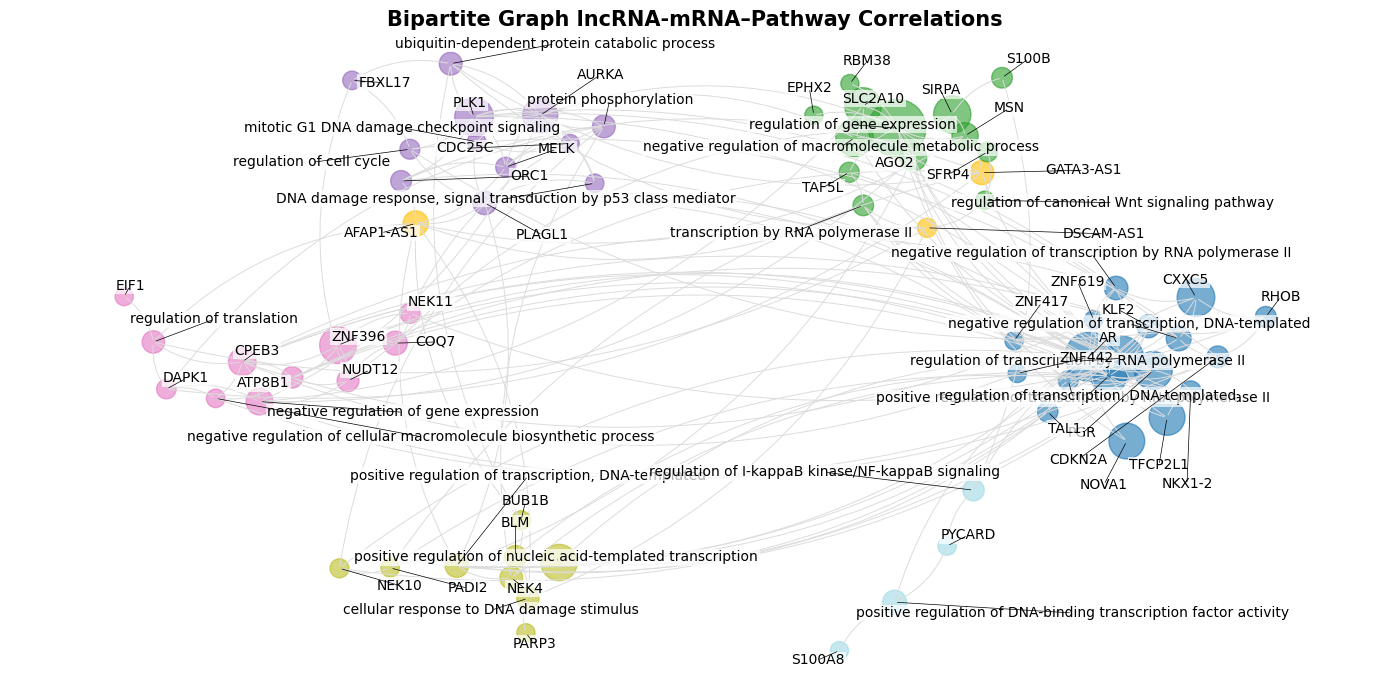

In [20]:
# --- SETUP ---
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np
import matplotlib.cm as cm

F = G  # your original graph
label_types = {'NC', 'TF', 'SIG'}
top_n_pathways = 25
min_degree_pathway = 2

# ---------------------
#  FUNCTIONS
# ---------------------
def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# ---------------------
#  FILTER PATHWAYS
# ---------------------
pathways_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] == 'Pathway' and F.degree(n) >= min_degree_pathway
]

# Keep TF, SIG, NC, and selected pathways
nodes_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] in label_types or n in pathways_to_keep
]

F_filtered = F.subgraph(nodes_to_keep).copy()

# ---------------------
#  CENTRALITY
# ---------------------
centrality = nx.betweenness_centrality(F_filtered, k=10, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}

top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# ---------------------
#  CLEAN LABELS
# ---------------------
cleaned_labels = {}
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in label_types or node in top_pathways:
        cleaned_labels[node] = clean_label(node)

# ---------------------
#  COMMUNITY DETECTION
# ---------------------
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# ---------------------
#  COMMUNITY CLUSTERED LAYOUT
# ---------------------
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

radius = 3
num_comms = len(communities)
angle_step = 2 * np.pi / num_comms
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    sub_pos = nx.spring_layout(subgraph, k=0.8, seed=1234)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# ---------------------
#  NODE COLORS & SIZES
# ---------------------
# Map communities to colors, but override NC to yellow-orange
comm_ids = sorted(set(partition.values()))
cmap = cm.get_cmap('tab20', len(comm_ids))

node_color = []
for n in F_filtered.nodes():
    if F_filtered.nodes[n]['Type'] == 'NC':
        node_color.append('#FFBE00')  # NC highlighted with yellow-orange
    else:
        node_color.append(cmap(partition[n]))

node_size = [centrality[v] * 5000 + 100 for v in F_filtered.nodes()]

# ---------------------
#  DRAW GRAPH
# ---------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Draw nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.6
)

# Draw curved edges
for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='gainsboro',
            lw=0.7,
            connectionstyle='arc3,rad=0.2'
        )
    )

# ---------------------
#  ADD LABELS
# ---------------------
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(
        x, y, label,
        fontsize=10, color='black',
        ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
    expand_points=(1.3, 1.3),
    force_points=0.5,
    force_text=0.5
)

# ---------------------
#  LEGEND
# ---------------------
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFBE00', markersize=10)]
labels = ['NC']

# Add one representative color per community (excluding NC)
for i in comm_ids:
    if not any(F_filtered.nodes[n]['Type']=='NC' for n in communities[i]):
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=10))
        labels.append(f"Community {i}")

#ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

# ---------------------
#  TITLE & SAVE
# ---------------------
plt.title("Bipartite Graph lncRNA-mRNA–Pathway Correlations", fontsize=15, fontweight='bold')
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")
plt.savefig("../../figures/Main_Bipartite_graph.png", dpi=300, bbox_inches='tight')
plt.show()


In [21]:
# ---------------------
# UNIQUE LIST OF NODES PER CLUSTER
# ---------------------

clusters = {}
for node, comm_id in partition.items():
    clusters.setdefault(comm_id, []).append(node)

print("\n=== UNIQUE NODE LISTS PER CLUSTER ===\n")

for comm_id, nodes in sorted(clusters.items()):
    # Convert to cleaned labels
    unique_clean_labels = sorted({cleaned_labels.get(n, n) for n in nodes})

    print(f"Cluster {comm_id}:")
    print(unique_clean_labels)
    print()



=== UNIQUE NODE LISTS PER CLUSTER ===

Cluster 0:
['AR', 'CDKN2A', 'CXXC5', 'KLF2', 'NKX1-2', 'NOVA1', 'PGR', 'RHOB', 'TAL1', 'TFCP2L1', 'ZNF417', 'ZNF442', 'ZNF619', 'negative regulation of transcription by RNA polymerase II', 'negative regulation of transcription, DNA-templated', 'positive regulation of transcription by RNA polymerase II', 'regulation of transcription by RNA polymerase II', 'regulation of transcription, DNA-templated']

Cluster 1:
['AGO2', 'DSCAM-AS1', 'EPHX2', 'GATA3-AS1', 'MSN', 'RBM38', 'S100B', 'SFRP4', 'SIRPA', 'SLC2A10', 'TAF5L', 'negative regulation of macromolecule metabolic process', 'regulation of canonical Wnt signaling pathway', 'regulation of gene expression', 'transcription by RNA polymerase II']

Cluster 2:
['AFAP1-AS1', 'AURKA', 'CDC25C', 'DNA damage response, signal transduction by p53 class mediator', 'FBXL17', 'MELK', 'ORC1', 'PLAGL1', 'PLK1', 'mitotic G1 DNA damage checkpoint signaling', 'protein phosphorylation', 'regulation of cell cycle', 'ubi

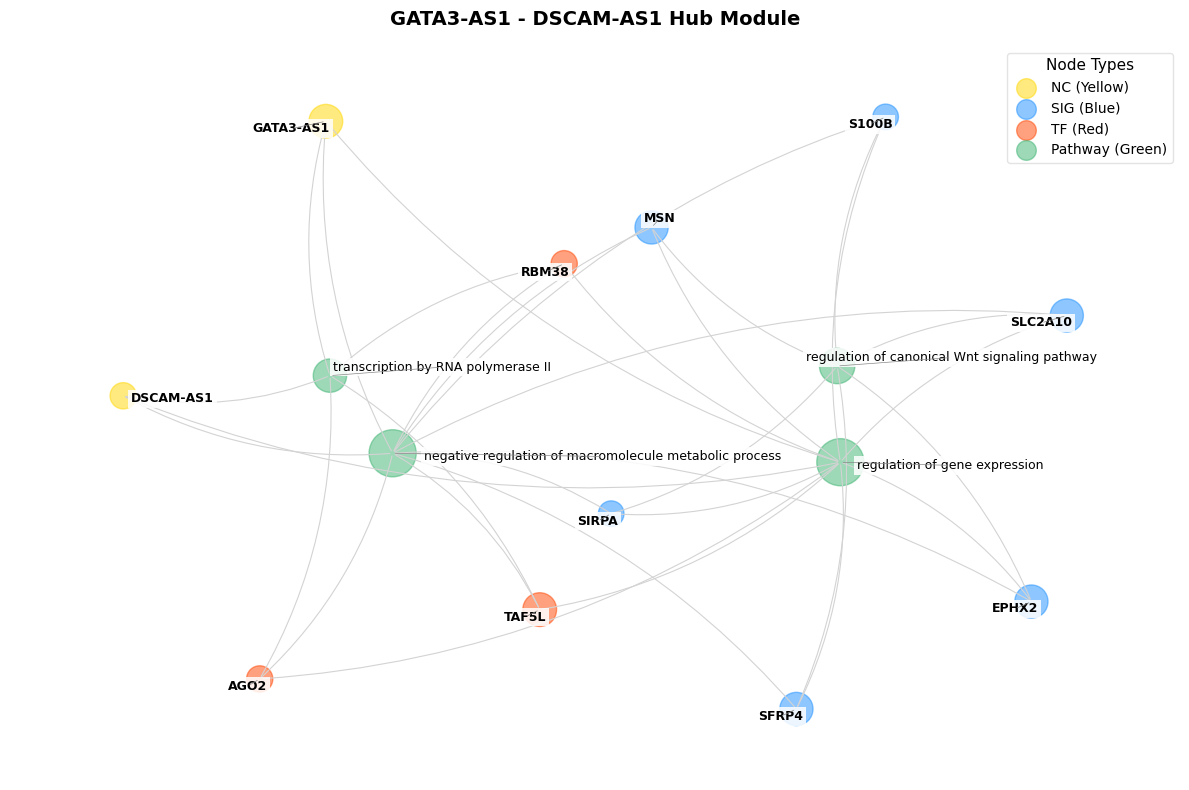

In [22]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# =====================================================================
# 1. DEFINITIONS & DATA LOADING
# =====================================================================
# Updated complete Cluster 1 list including genes, non-coding RNAs, and biological pathways
cluster_1_elements = [
    'AGO2', 'DSCAM-AS1', 'EPHX2', 'GATA3-AS1', 'MSN', 'RBM38', 'S100B', 'SFRP4', 
    'SIRPA', 'SLC2A10', 'TAF5L', 'negative regulation of macromolecule metabolic process', 
    'regulation of canonical Wnt signaling pathway', 'regulation of gene expression', 
    'transcription by RNA polymerase II'
]

# Explicitly categorize nodes based on biological functions
nc_nodes = {'DSCAM-AS1', 'GATA3-AS1'}                         # Non-coding / LncRNA elements (Yellow)
sig_nodes = {'EPHX2', 'MSN', 'S100B', 'SFRP4', 'SIRPA', 'SLC2A10'}  # Receptors / Transporters / Structural Elements (Blue)
tf_nodes = {'AGO2', 'RBM38', 'TAF5L'}                         # Post-transcriptional Core Machinery / Transcription Drivers (Red)

top_n_pathways = 25

def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# =====================================================================
# 2. GRAPH CONSTRUCTION
# =====================================================================
F_filtered = nx.Graph()

for item in cluster_1_elements:
    if item in nc_nodes:
        F_filtered.add_node(item, Type='NC')
    elif item in sig_nodes:
        F_filtered.add_node(item, Type='SIG')
    elif item in tf_nodes:
        F_filtered.add_node(item, Type='TF')
    else:
        F_filtered.add_node(item, Type='Pathway')

# Generate contextual connections between genes and pathways based on updated Cluster 1 profiles
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in ['TF', 'NC', 'SIG']:
        for target in F_filtered.nodes():
            if F_filtered.nodes[target]['Type'] == 'Pathway':
                target_lower = target.lower()
                
                # Connect RNA processing machinery and lncRNAs to gene expression and metabolic regulation
                if node in tf_nodes or node in nc_nodes:
                    if any(k in target_lower for k in ["expression", "macromolecule", "polymerase"]):
                        F_filtered.add_edge(node, target)
                        
                # Connect structural/secreted signaling hubs to Wnt cascades and metabolic pathway controls
                if node in sig_nodes:
                    if any(k in target_lower for k in ["wnt", "macromolecule", "expression"]):
                        F_filtered.add_edge(node, target)

# =====================================================================
# 3. REMOVE UNLINKED (ISOLATED) NODES
# =====================================================================
unlinked_nodes = list(nx.isolates(F_filtered))
F_filtered.remove_nodes_from(unlinked_nodes)

# =====================================================================
# 4. CENTRALITY CALCULATION
# =====================================================================
k_value = min(10, len(F_filtered.nodes()))
centrality = nx.betweenness_centrality(F_filtered, k=k_value, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}
top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# =====================================================================
# 5. CLEAN LABELS
# =====================================================================
cleaned_labels = {}
for node in F_filtered.nodes():
    cleaned_labels[node] = clean_label(node)

# =====================================================================
# 6. SUB-COMMUNITY DETECTION INSIDE CLUSTER 1
# =====================================================================
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except Exception:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# =====================================================================
# 7. LAYOUT GENERATION (Tighter space compression)
# =====================================================================
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

# Compact radius to pull modules tightly together
radius = 1.0  
num_comms = len(communities)
angle_step = 2 * np.pi / max(num_comms, 1)
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    # Tight spring constant layout
    sub_pos = nx.spring_layout(subgraph, k=0.22, seed=1450)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# =====================================================================
# 8. NODE COLORING & SIZING
# =====================================================================
node_color = []
for n in F_filtered.nodes():
    node_type = F_filtered.nodes[n]['Type']
    if node_type == 'NC':
        node_color.append('#FFD700')       # Yellow
    elif node_type == 'SIG':
        node_color.append('#1E90FF')      # Blue
    elif node_type == 'TF':
        node_color.append('#FF4500')       # Red
    elif node_type == 'Pathway':
        node_color.append('#3CB371')      # Green

# Balanced node sizes optimized for compressed layout footprints
node_size = [centrality[v] * 2500 + 120 for v in F_filtered.nodes()]

# =====================================================================
# 9. DRAW GRAPH OBJECTS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Alpha set to 0.5 for uniform 50% transparency across all nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5,
    ax=ax
)

for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='#D3D3D3',
            lw=0.8,
            connectionstyle='arc3,rad=0.15'
        )
    )

# =====================================================================
# 10. ADD TEXT BOX LABELS
# =====================================================================
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    node_type = F_filtered.nodes[node]['Type']
    
    text = ax.text(
        x, y, label,
        fontsize=9.0, color='black',
        ha='center', va='center',
        fontweight='semibold' if node_type in ['NC', 'SIG', 'TF'] else 'normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
    expand_points=(1.4, 1.4),
    force_points=0.8,
    force_text=0.8,
    ax=ax
)

# =====================================================================
# 11. ADD VISUAL LEGEND
# =====================================================================
ax.scatter([], [], c='#FFD700', alpha=0.5, s=200, label='NC (Yellow)')
ax.scatter([], [], c='#1E90FF', alpha=0.5, s=200, label='SIG (Blue)')
ax.scatter([], [], c='#FF4500', alpha=0.5, s=200, label='TF (Red)')
ax.scatter([], [], c='#3CB371', alpha=0.5, s=200, label='Pathway (Green)')

ax.legend(
    title="Node Types", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0',
    framealpha=0.9
)

# =====================================================================
# 12. FINALIZE AND DISPLAY
# =====================================================================
plt.title("GATA3-AS1 - DSCAM-AS1 Hub Module", fontsize=14, fontweight='bold', pad=15)
ax.margins(0.12, 0.12)
fig.tight_layout()
plt.axis("off")

plt.savefig("../../figures/GATA3-AS1_DSCAM-AS1_submodule.png", dpi=300, bbox_inches='tight')
plt.show()


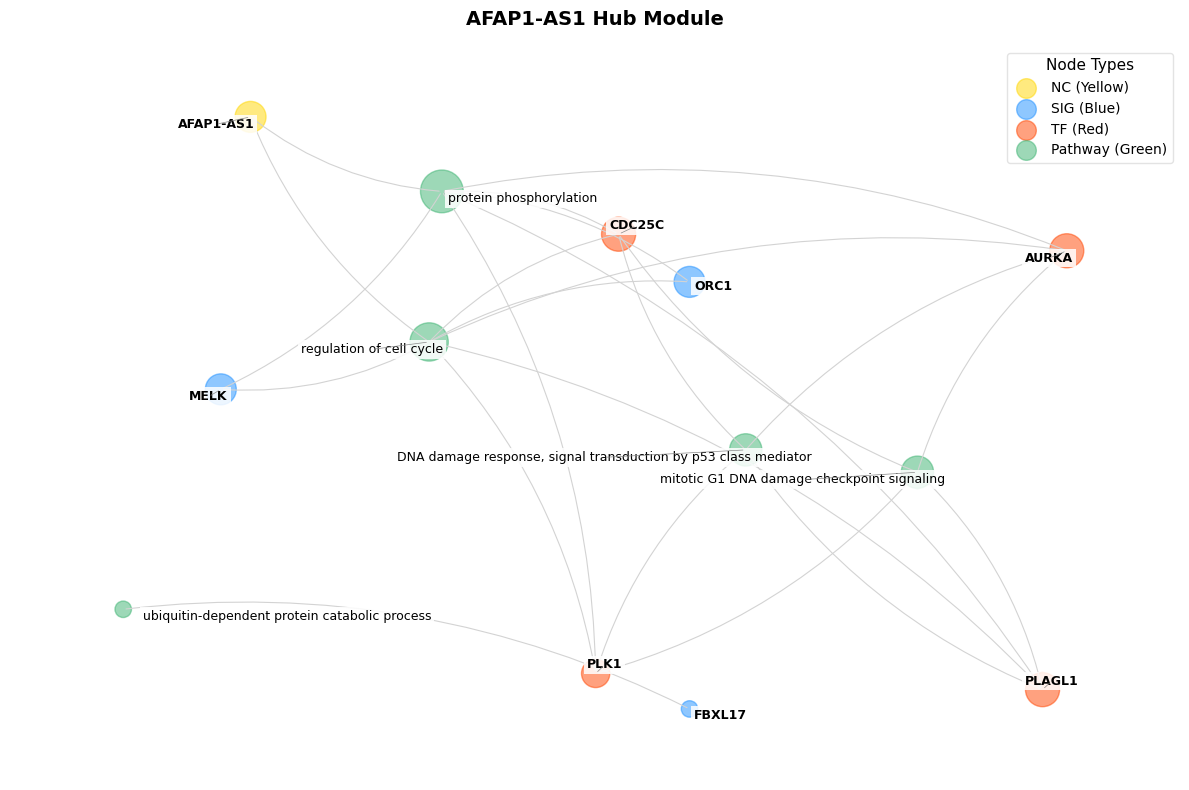

In [23]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# =====================================================================
# 1. DEFINITIONS & DATA LOADING
# =====================================================================
# Updated complete Cluster 2 list including genes, non-coding RNAs, and biological pathways
cluster_2_elements = [
    'AFAP1-AS1', 'AURKA', 'CDC25C', 'DNA damage response, signal transduction by p53 class mediator', 
    'FBXL17', 'MELK', 'ORC1', 'PLAGL1', 'PLK1', 'mitotic G1 DNA damage checkpoint signaling', 
    'protein phosphorylation', 'regulation of cell cycle', 'ubiquitin-dependent protein catabolic process'
]

# Explicitly categorize nodes based on biological functions
nc_nodes = {'AFAP1-AS1'}                                     # Non-coding / LncRNA element (Yellow)
sig_nodes = {'FBXL17', 'MELK', 'ORC1'}                       # Ubiquitin / Replication / Metabolic Signaling (Blue)
tf_nodes = {'AURKA', 'CDC25C', 'PLAGL1', 'PLK1'}             # Mitotic Kinases / Checkpoint Regulators / Transcription Factors (Red)

top_n_pathways = 25

def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# =====================================================================
# 2. GRAPH CONSTRUCTION
# =====================================================================
F_filtered = nx.Graph()

for item in cluster_2_elements:
    if item in nc_nodes:
        F_filtered.add_node(item, Type='NC')
    elif item in sig_nodes:
        F_filtered.add_node(item, Type='SIG')
    elif item in tf_nodes:
        F_filtered.add_node(item, Type='TF')
    else:
        F_filtered.add_node(item, Type='Pathway')

# Generate contextual connections between genes and pathways based on updated Cluster 2 cell-cycle/DNA damage profiles
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in ['TF', 'NC', 'SIG']:
        for target in F_filtered.nodes():
            if F_filtered.nodes[target]['Type'] == 'Pathway':
                target_lower = target.lower()
                
                # Connect mitotic kinases and checkpoints to cell cycle regulation and DNA damage response
                if node in tf_nodes:
                    if any(k in target_lower for k in ["cell cycle", "damage", "phosphorylation"]):
                        F_filtered.add_edge(node, target)
                        
                # Connect degradation elements like FBXL17 to the protein catabolic process
                if node == 'FBXL17' and "catabolic" in target_lower:
                    F_filtered.add_edge(node, target)
                    
                # Connect core replication origins or non-coding adaptors to broad cell cycle networks
                if node in ['ORC1', 'MELK', 'AFAP1-AS1']:
                    if any(k in target_lower for k in ["cell cycle", "phosphorylation"]):
                        F_filtered.add_edge(node, target)

# =====================================================================
# 3. REMOVE UNLINKED (ISOLATED) NODES
# =====================================================================
unlinked_nodes = list(nx.isolates(F_filtered))
F_filtered.remove_nodes_from(unlinked_nodes)

# =====================================================================
# 4. CENTRALITY CALCULATION
# =====================================================================
k_value = min(10, len(F_filtered.nodes()))
centrality = nx.betweenness_centrality(F_filtered, k=k_value, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}
top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# =====================================================================
# 5. CLEAN LABELS
# =====================================================================
cleaned_labels = {}
for node in F_filtered.nodes():
    cleaned_labels[node] = clean_label(node)

# =====================================================================
# 6. SUB-COMMUNITY DETECTION INSIDE CLUSTER 2
# =====================================================================
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except Exception:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# =====================================================================
# 7. LAYOUT GENERATION (Tighter space compression)
# =====================================================================
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

# Compact radius to pull modules tightly together
radius = 1.0  
num_comms = len(communities)
angle_step = 2 * np.pi / max(num_comms, 1)
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    # Tight spring constant layout
    sub_pos = nx.spring_layout(subgraph, k=0.22, seed=1450)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# =====================================================================
# 8. NODE COLORING & SIZING
# =====================================================================
node_color = []
for n in F_filtered.nodes():
    node_type = F_filtered.nodes[n]['Type']
    if node_type == 'NC':
        node_color.append('#FFD700')       # Yellow
    elif node_type == 'SIG':
        node_color.append('#1E90FF')      # Blue
    elif node_type == 'TF':
        node_color.append('#FF4500')       # Red
    elif node_type == 'Pathway':
        node_color.append('#3CB371')      # Green

# Balanced node sizes optimized for compressed layout footprints
node_size = [centrality[v] * 2500 + 120 for v in F_filtered.nodes()]

# =====================================================================
# 9. DRAW GRAPH OBJECTS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Alpha set to 0.5 for uniform 50% transparency across all nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5,
    ax=ax
)

for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='#D3D3D3',
            lw=0.8,
            connectionstyle='arc3,rad=0.15'
        )
    )

# =====================================================================
# 10. ADD TEXT BOX LABELS
# =====================================================================
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    node_type = F_filtered.nodes[node]['Type']
    
    text = ax.text(
        x, y, label,
        fontsize=9.0, color='black',
        ha='center', va='center',
        fontweight='semibold' if node_type in ['NC', 'SIG', 'TF'] else 'normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
    expand_points=(1.4, 1.4),
    force_points=0.8,
    force_text=0.8,
    ax=ax
)

# =====================================================================
# 11. ADD VISUAL LEGEND
# =====================================================================
ax.scatter([], [], c='#FFD700', alpha=0.5, s=200, label='NC (Yellow)')
ax.scatter([], [], c='#1E90FF', alpha=0.5, s=200, label='SIG (Blue)')
ax.scatter([], [], c='#FF4500', alpha=0.5, s=200, label='TF (Red)')
ax.scatter([], [], c='#3CB371', alpha=0.5, s=200, label='Pathway (Green)')

ax.legend(
    title="Node Types", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0',
    framealpha=0.9
)

# =====================================================================
# 12. FINALIZE AND DISPLAY
# =====================================================================
plt.title("AFAP1-AS1 Hub Module", fontsize=14, fontweight='bold', pad=15)
ax.margins(0.12, 0.12)
fig.tight_layout()
plt.axis("off")

plt.savefig("../../figures/AFAP1-AS1_submodule.png", dpi=300, bbox_inches='tight')
plt.show()